# 03 · The mood of music over time

**The question:** does the emotional tone of music shift across the century? We chart `valence` (musical positivity), `energy`, and `danceability`, look at whole *distributions* (not just averages), and trace music's path through 'mood-space'.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'analysis'))
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
from common import load_genre, load_timeline, AUDIO, zscore
df = load_timeline()
EVENTS = {1929:'Depression', 1945:'WWII ends', 1969:'Woodstock', 1981:'MTV',
          2008:'Financial crisis', 2020:'COVID'}
yr = df.groupby('year')[['valence','energy','danceability']].mean()
yr.tail(3)

,valence,energy,danceability
year,,,
2019,0.494212,0.637066,0.649724
2020,0.501712,0.639669,0.657129
2021,0.506228,0.617998,0.671531


## Step 1 — Three emotional signals across a century

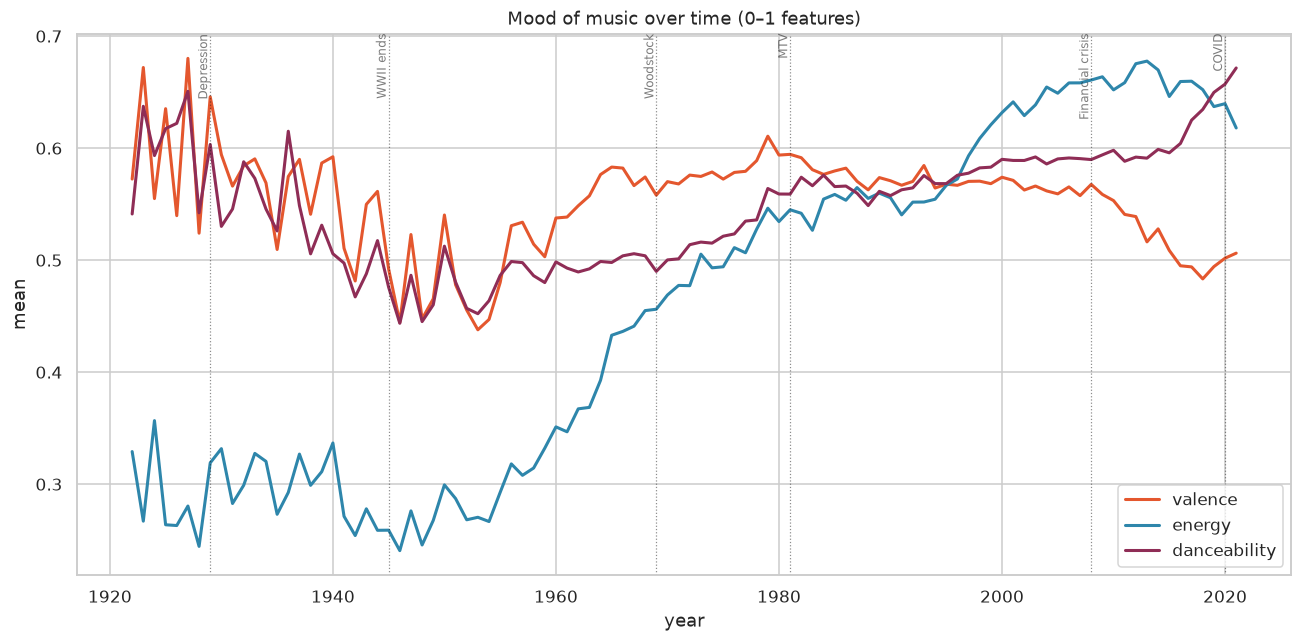

In [2]:
plt.figure(figsize=(12, 6))
for f, c in [('valence','#e4572e'), ('energy','#2e86ab'), ('danceability','#8f2d56')]:
    plt.plot(yr.index, yr[f], label=f, color=c, lw=2)
for y0, name in EVENTS.items():
    plt.axvline(y0, color='k', ls=':', lw=.8, alpha=.5)
    plt.text(y0, plt.ylim()[1], name, rotation=90, va='top', ha='right', fontsize=8, alpha=.6)
plt.title('Mood of music over time (0–1 features)')
plt.xlabel('year'); plt.ylabel('mean'); plt.legend(); plt.tight_layout(); plt.show()

## Step 2 — Not just the average: the whole distribution per decade
Averages can hide things. These violins show the full spread of `valence` and `energy` within each decade — energy clearly marches up and its distribution shifts wholesale.

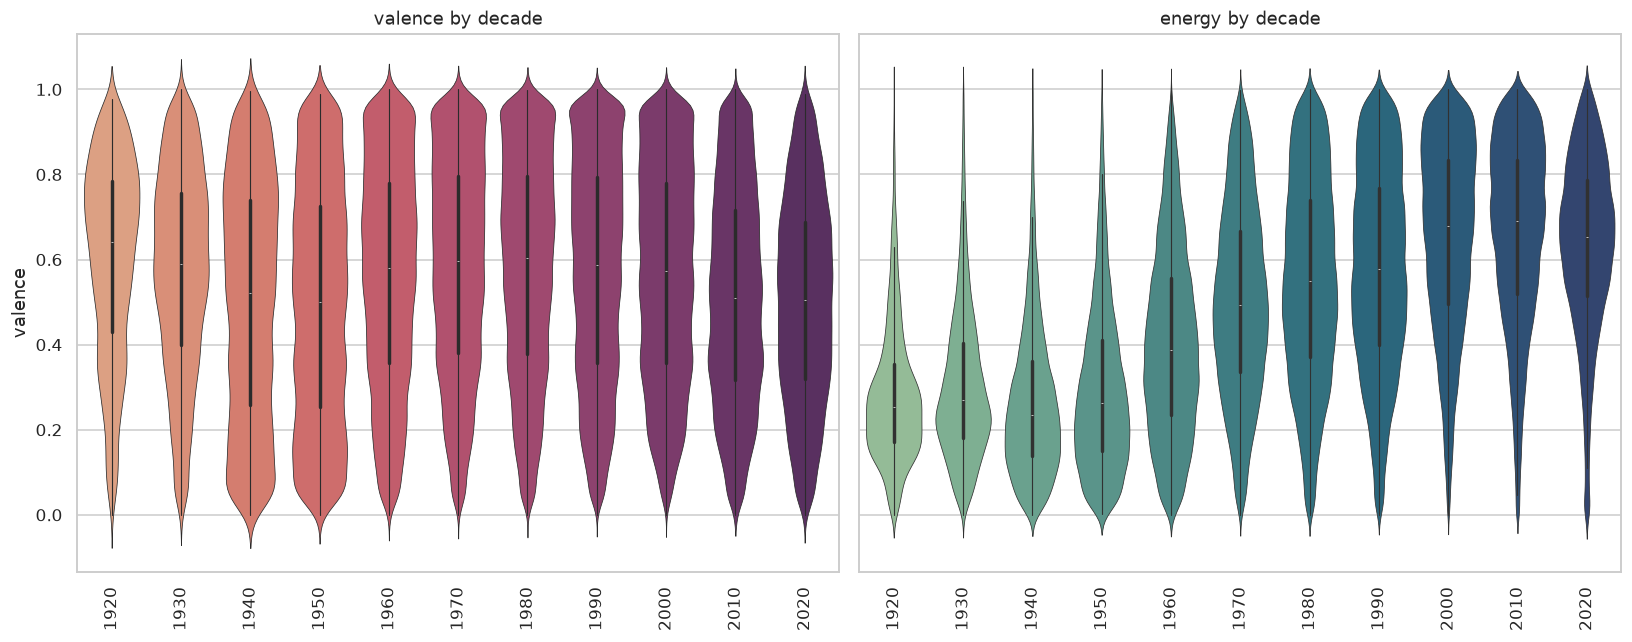

In [3]:
dv = df.assign(decade=df.decade.astype(str))
order = [str(d) for d in sorted(df.decade.unique())]
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, f, cmap in [(axes[0],'valence','flare'), (axes[1],'energy','crest')]:
    sns.violinplot(dv, x='decade', y=f, order=order, ax=ax, hue='decade', hue_order=order,
                   legend=False, density_norm='width', linewidth=.5, palette=cmap)
    ax.set_title(f'{f} by decade'); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()

## Step 3 — Music's path through 'mood-space'
Plot each decade's average position on the valence×energy plane (the classic mood quadrants). The arrow of time shows music drifting from *calm/positive* toward *intense*.

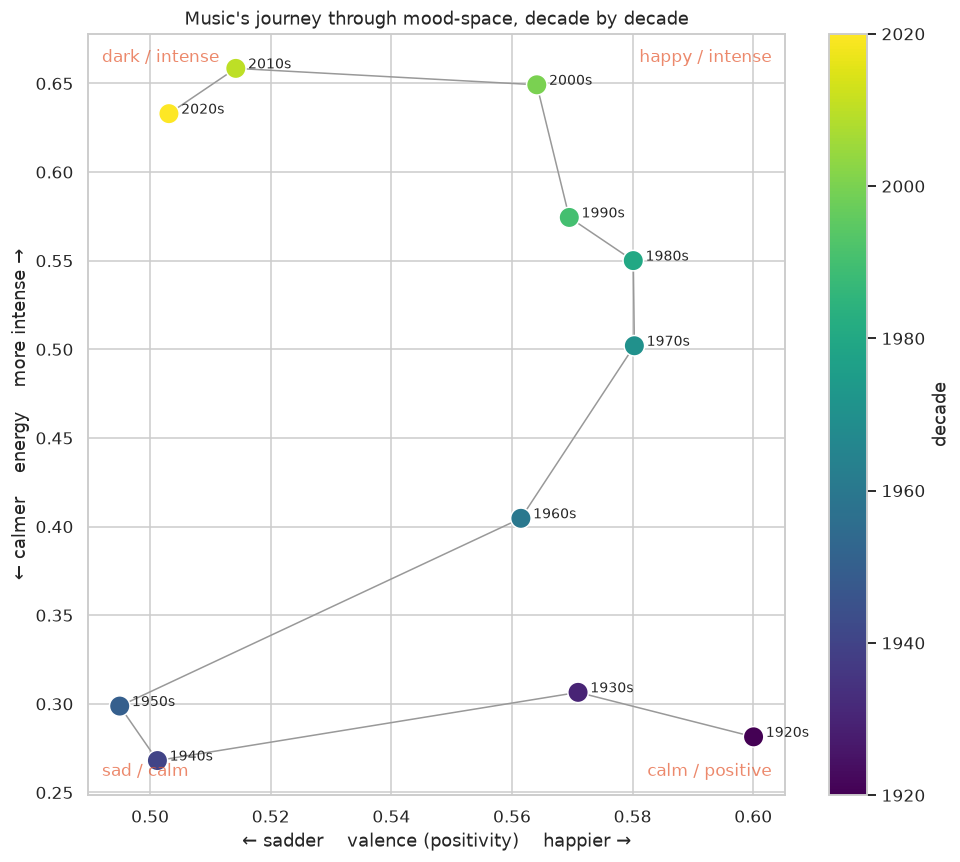

In [4]:
me = df.groupby('decade')[['valence','energy']].mean()
fig, ax = plt.subplots(figsize=(9, 8))
ax.plot(me['valence'], me['energy'], '-', color='#999', lw=1, zorder=1)
sc = ax.scatter(me['valence'], me['energy'], c=me.index, cmap='viridis', s=180, zorder=2,
                edgecolor='white')
for d, r in me.iterrows(): ax.annotate(f'{d}s', (r['valence'], r['energy']),
                                       textcoords='offset points', xytext=(8, 0), fontsize=9)
# quadrant labels anchored to the axes corners (data is zoomed, so use axes fractions)
for q, xy, ha, va in [('calm / positive',(.98,.02),'right','bottom'),
                      ('happy / intense',(.98,.98),'right','top'),
                      ('sad / calm',(.02,.02),'left','bottom'),
                      ('dark / intense',(.02,.98),'left','top')]:
    ax.text(*xy, q, transform=ax.transAxes, ha=ha, va=va, color='#e4572e', alpha=.7, fontsize=11)
fig.colorbar(sc, ax=ax, label='decade'); ax.set_xlabel('← sadder    valence (positivity)    happier →')
ax.set_ylabel('← calmer    energy    more intense →')
ax.set_title("Music's journey through mood-space, decade by decade")
plt.tight_layout(); plt.show()

In [5]:
for lo, hi in [(1960,1969), (2010,2019)]:
    v, e = yr.loc[lo:hi,'valence'].mean(), yr.loc[lo:hi,'energy'].mean()
    print(f'{lo}s: valence {v:.3f} · energy {e:.3f}')

1960s: valence 0.562 · energy 0.405
2010s: valence 0.515 · energy 0.659


## Verdict
**Energy nearly doubles** over the century while **valence quietly declines**, sharply after 2000 — modern music is *louder and more intense but less overtly happy.* The mood-space path makes the drift vivid. This is correlational, though: a causal read would join an economic / sentiment series (misery index) — see *what's next*.